In [1]:
#Titanic dataset analysis 
##what is the data about :: the data provides  insights about the passengers and their survival  the oher data information is interlinked with the survival of the passengers as well

#final breakdown 
#loading dataset

!pip install pandas 
!pip install pandas numpy scikit-learn matplotlib seaborn
!pip install matplotlib


In [3]:
#importing data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#loading dataset
data  = pd.read_csv("titanic.csv.csv")
data.columns = data.columns.str.strip()

pd.set_option('display.max_columns', None)

print(data.head())
print(data.info())
print(data.describe())

data.isnull()

   Survived  Pclass                                               Name  \
0       0.0     3.0                             Mr. Owen Harris Braund   
1       1.0     1.0  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2       1.0     3.0                              Miss. Laina Heikkinen   
3       1.0     1.0        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4       0.0     3.0                            Mr. William Henry Allen   

      Sex   Age  Sibsp  Parch     Fare Embarked  
0    male  22.0    1.0    0.0   7.2500        S  
1  female  38.0    1.0    0.0  71.2833        C  
2  female  26.0    0.0    0.0   7.9250        S  
3  female  35.0    1.0    0.0  53.1000        S  
4    male  35.0    0.0    0.0   8.0500        S  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  887 non-null    float64
 1   Pclass    887 non-null    float64
 2   N

,Survived,Pclass,Name,Sex,Age,Sibsp,Parch,Fare,Embarked
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False
887,True,True,True,True,True,True,True,True,False
888,True,True,True,True,True,True,True,True,False
889,True,True,True,True,True,True,True,True,False


In [ ]:
print(data)
print(data.columns.tolist())
print(data.head())

     Survived  Pclass                                               Name  \
0         0.0     3.0                             Mr. Owen Harris Braund   
1         1.0     1.0  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2         1.0     3.0                              Miss. Laina Heikkinen   
3         1.0     1.0        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4         0.0     3.0                            Mr. William Henry Allen   
..        ...     ...                                                ...   
886       0.0     3.0                                 Mr. Patrick Dooley   
887       NaN     NaN                                                NaN   
888       NaN     NaN                                                NaN   
889       NaN     NaN                                                NaN   
890       NaN     NaN                                                NaN   

        Sex   Age  Sibsp  Parch     Fare Embarked  
0      male  22.0    1.0    0.0   7

In [ ]:
# MISSING VALUES
print("\nMISSING VALUES")
print(data.isnull().sum())


MISSING VALUES
Survived    4
Pclass      4
Name        4
Sex         4
Age         4
Sibsp       4
Parch       4
Fare        4
Embarked    2
dtype: int64


Male Count: 573
Female Count: 314
Children (<18) Count: 130


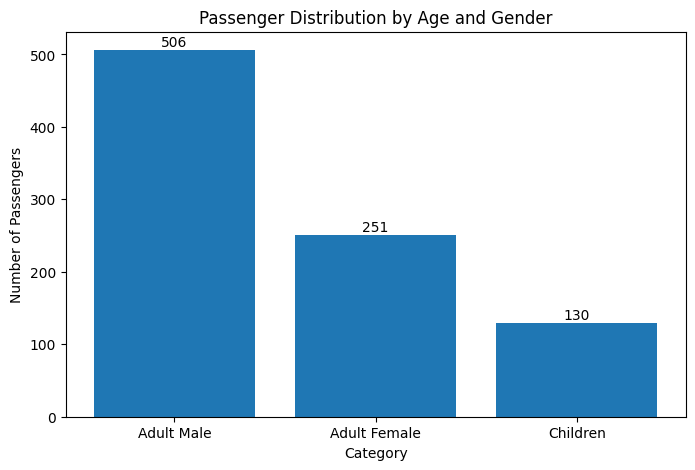

In [ ]:
# Count males and females
male_count = (data["Sex"] == "male").sum()
female_count = (data["Sex"] == "female").sum()

# Count children (Age < 18)
children_count = (data["Age"] < 18).sum()

# Print results
print("Male Count:", male_count)
print("Female Count:", female_count)
print("Children (<18) Count:", children_count)

# Exclusive categories
adult_males = len(
    data[
        (data["Sex"] == "male") &
        (data["Age"] >= 18)
    ]
)

adult_females = len(
    data[
        (data["Sex"] == "female") &
        (data["Age"] >= 18)
    ]
)

children = len(
    data[
        (data["Age"] < 18)
    ]
)

# Data for plot
categories = ["Adult Male", "Adult Female", "Children"]
counts = [adult_males, adult_females, children]

# Create bar graph
plt.figure(figsize=(8, 5))
plt.bar(categories, counts)

plt.title("Passenger Distribution by Age and Gender")
plt.xlabel("Category")
plt.ylabel("Number of Passengers")

# Display values on bars
for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha="center")

plt.show()


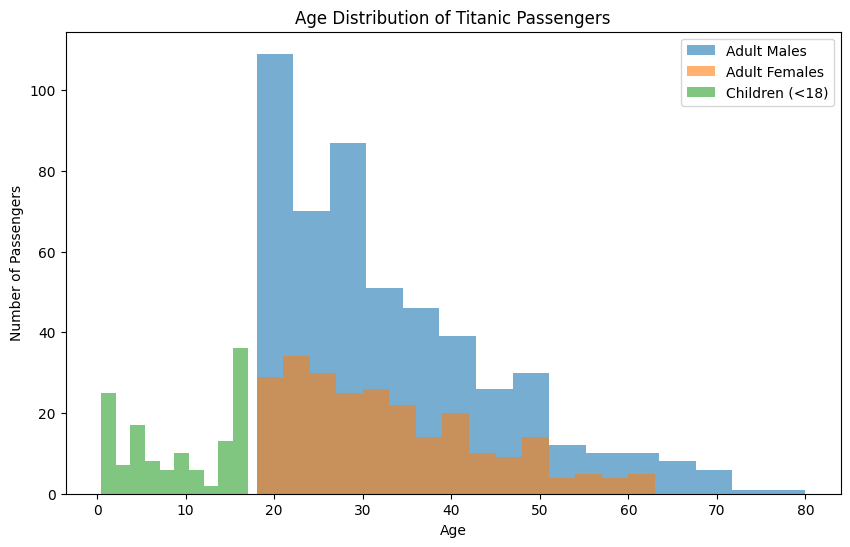

In [ ]:
# Create groups
adult_males = data[
    (data["Sex"] == "male") &
    (data["Age"] >= 18)
]["Age"].dropna()

adult_females = data[
    (data["Sex"] == "female") &
    (data["Age"] >= 18)
]["Age"].dropna()

children = data[
    data["Age"] < 18
]["Age"].dropna()

# Plot histogram
plt.figure(figsize=(10, 6))

plt.hist(adult_males, bins=15, alpha=0.6, label="Adult Males")
plt.hist(adult_females, bins=15, alpha=0.6, label="Adult Females")
plt.hist(children, bins=10, alpha=0.6, label="Children (<18)")

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()

plt.show()

In [ ]:
#to find average age  median age  oldest and youngest passenger 
# Average age (mean)
average_age = data["Age"].mean()

# Median age
median_age = data["Age"].median()

print("Average Age:", average_age)
print("Median Age:", median_age)

# Find oldest passenger
oldest = data.loc[data["Age"].idxmax()]

# Find youngest passenger
youngest = data.loc[data["Age"].idxmin()]

print("OLDEST PASSENGER")
print("Name :", oldest["Name"])
print("Age  :", oldest["Age"])

print("\nYOUNGEST PASSENGER")
print("Name :", youngest["Name"])
print("Age  :", youngest["Age"])

Average Age: 29.471443066516347
Median Age: 28.0
OLDEST PASSENGER
Name : Mr. Algernon Henry Wilson Barkworth
Age  : 80.0

YOUNGEST PASSENGER
Name : Master. Assad Alexander Thomas
Age  : 0.42


In [ ]:
# Age statistics by gender
age_distribution = data.groupby("Sex")["Age"].agg(
    ["count", "mean", "median", "min", "max"]
)

print(age_distribution)

        count       mean  median   min   max
Sex                                         
female    314  27.719745    27.0  0.75  63.0
male      573  30.431361    28.0  0.42  80.0


In [ ]:
# Find unique classes
classes = data["Pclass"].unique()

print("Classes in the ship:", classes)
print("Number of classes:", len(classes))

# Number of passengers in each class
print("Passengers in each class:")
print(data["Pclass"].value_counts().sort_index())

print("\nMale and Female distribution in each class:")

# Gender distribution by class
gender_distribution = pd.crosstab(
    data["Pclass"],
    data["Sex"]
)

print(gender_distribution)

Classes in the ship: [ 3.  1.  2. nan]
Number of classes: 4
Passengers in each class:
Pclass
1.0    216
2.0    184
3.0    487
Name: count, dtype: int64

Male and Female distribution in each class:
Sex     female  male
Pclass              
1.0         94   122
2.0         76   108
3.0        144   343


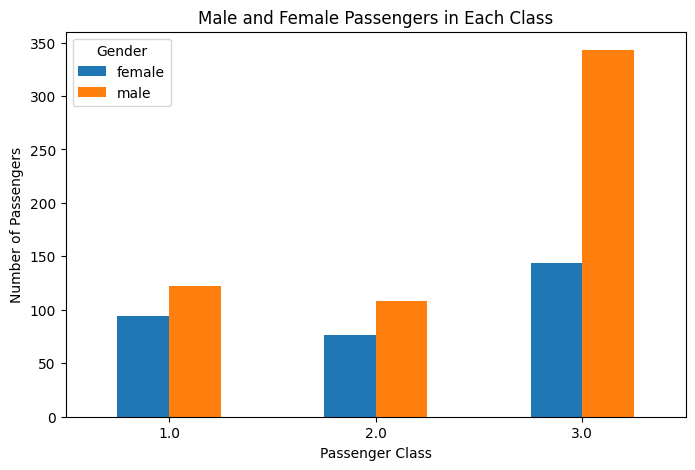

In [ ]:
import matplotlib.pyplot as plt

gender_class = pd.crosstab(data["Pclass"], data["Sex"])

gender_class.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Male and Female Passengers in Each Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.legend(title="Gender")

plt.show()

In [ ]:

count = (data["Sibsp"] > 0).sum()

print("Passengers with spouses/siblings aboard:", count)

#to see full distrubition of sib/sp
distribution = data["Sibsp"].value_counts().sort_index()

print(distribution)

sibsp_1 = data[data["Sibsp"] == 1]

print("CLASS DISTRIBUTION FOR PASSENGERS WITH 1 SIBLING/SPOUSE")
print("-" * 50)
for cls, count in sibsp_1["Pclass"].value_counts().sort_index().items():
    print(f"Class {cls}: {count} passengers")

most_used = sibsp_1["Pclass"].mode()[0]

print("-" * 50)
print(f"Most used class: Class {most_used}")

# Find maximum SibSp value
max_sibsp = data["Sibsp"].max()

# Passengers having the maximum number of siblings/spouses
max_sibsp_passengers = data[data["Sibsp"] == max_sibsp]

print(f"Maximum Sibsp value: {max_sibsp}\n")

# Count classes
class_counts = max_sibsp_passengers["Pclass"].value_counts()

print("Class distribution:")
print(class_counts)

print("\nMost used class:")
print(class_counts.idxmax())

Passengers with spouses/siblings aboard: 283
Sibsp
0.0    604
1.0    209
2.0     28
3.0     16
4.0     18
5.0      5
8.0      7
Name: count, dtype: int64
CLASS DISTRIBUTION FOR PASSENGERS WITH 1 SIBLING/SPOUSE
--------------------------------------------------
Class 1.0: 71 passengers
Class 2.0: 55 passengers
Class 3.0: 83 passengers
--------------------------------------------------
Most used class: Class 3.0
Maximum Sibsp value: 8.0

Class distribution:
Pclass
3.0    7
Name: count, dtype: int64

Most used class:
3.0


<Figure size 800x500 with 0 Axes>

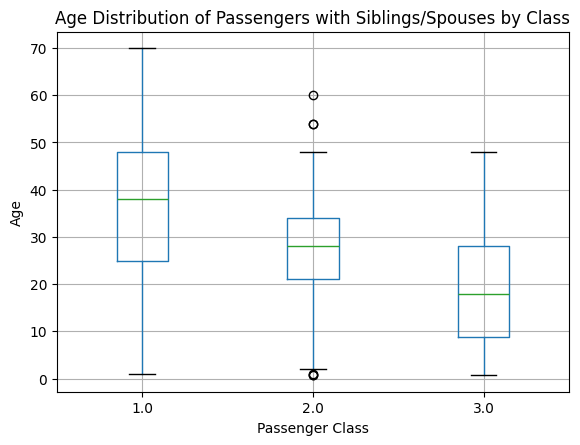

In [ ]:
#boxplot of age distribution for passengers with Sibsp for each class
data_with_sibsp = data[data["Sibsp"] > 0]

plt.figure(figsize=(8,5))
data_with_sibsp.boxplot(
    column="Age",
    by="Pclass"
)

plt.title("Age Distribution of Passengers with Siblings/Spouses by Class")
plt.suptitle("")
plt.xlabel("Passenger Class")
plt.ylabel("Age")

plt.show()

Passengers with SibSp = 1 by Class
Pclass
1.0    71
2.0    55
3.0    83
Name: count, dtype: int64


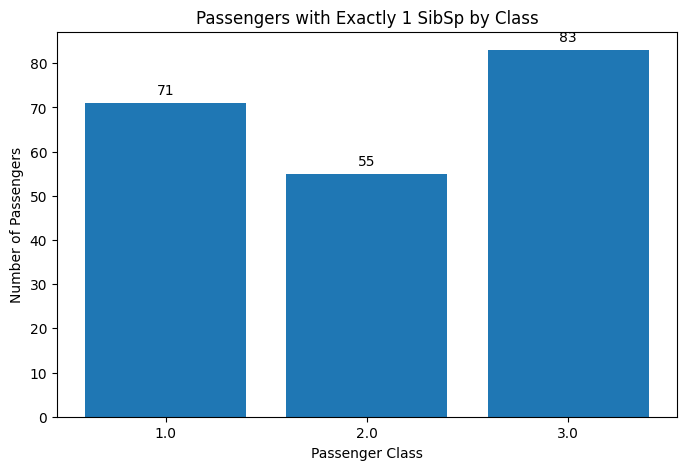


Most used class: Class 3.0


In [ ]:
# Passengers with exactly 1 sibling/spouse
sibsp_1 = data[data["Sibsp"] == 1]

# Count by class
class_counts = sibsp_1["Pclass"].value_counts().sort_index()

print("Passengers with SibSp = 1 by Class")
print(class_counts)

# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.title("Passengers with Exactly 1 SibSp by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

# Add values on bars
for i, count in enumerate(class_counts.values):
    plt.text(i, count + 2, str(count), ha="center")

plt.show()

# Most used class
most_used_class = class_counts.idxmax()
print(f"\nMost used class: Class {most_used_class}")

In [ ]:
# Distribution of Parents/Children aboard
parch_distribution = data["Parch"].value_counts().sort_index()

print("PARENTS / CHILDREN ABOARD DISTRIBUTION")
print("-" * 40)

for parch, count in parch_distribution.items():
    print(f"{parch} parent/child(ren): {count} passengers")

# Total passengers with at least one parent/child aboard
total_with_parch = (data["Parch"] > 0).sum()

print("-" * 40)
print(f"Total passengers with parents/children aboard: {total_with_parch}")

# Passengers with at least one parent/child aboard
with_parch = data[data["Parch"] > 0]

# Class distribution
class_distribution = with_parch["Pclass"].value_counts().sort_index()

print("CLASS DISTRIBUTION OF PASSENGERS WITH PARENTS/CHILDREN ABOARD")
print("-" * 60)

for cls, count in class_distribution.items():
    print(f"Class {cls}: {count} passengers")

print("-" * 60)
print(f"Total: {len(with_parch)} passengers")


PARENTS / CHILDREN ABOARD DISTRIBUTION
----------------------------------------
0.0 parent/child(ren): 674 passengers
1.0 parent/child(ren): 118 passengers
2.0 parent/child(ren): 80 passengers
3.0 parent/child(ren): 5 passengers
4.0 parent/child(ren): 4 passengers
5.0 parent/child(ren): 5 passengers
6.0 parent/child(ren): 1 passengers
----------------------------------------
Total passengers with parents/children aboard: 213
CLASS DISTRIBUTION OF PASSENGERS WITH PARENTS/CHILDREN ABOARD
------------------------------------------------------------
Class 1.0: 53 passengers
Class 2.0: 50 passengers
Class 3.0: 110 passengers
------------------------------------------------------------
Total: 213 passengers


Class Distribution of Passengers with Parch > 0
Pclass
1.0     53
2.0     50
3.0    110
Name: count, dtype: int64


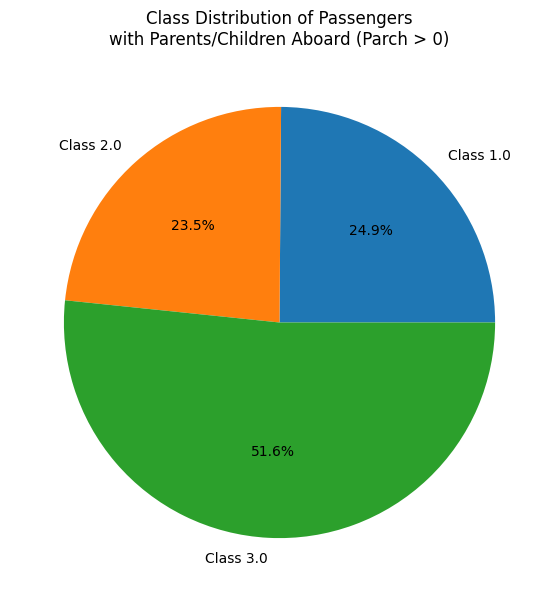

In [ ]:
# Passengers with at least one parent/child aboard
with_parch = data[data["Parch"] > 0]

# Count by class
class_counts = with_parch["Pclass"].value_counts().sort_index()

print("Class Distribution of Passengers with Parch > 0")
print(class_counts)

# Passengers with at least one parent/child aboard
with_parch = data[data["Parch"] > 0]

# Count passengers in each class
class_counts = with_parch["Pclass"].value_counts().sort_index()

# Labels
labels = [
    f"Class {cls}"
    for cls in class_counts.index
]

# Pie chart
plt.figure(figsize=(7, 7))

plt.pie(
    class_counts,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title(
    "Class Distribution of Passengers\nwith Parents/Children Aboard (Parch > 0)"
)

plt.show()

In [ ]:

# Sample data mimicking the Titanic dataset structure
data = {
    'PassengerId': [1, 2, 3, 4],
    'Name': ['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath'],
    'Sibsp': [1, 1, 0, 1],  # Number of Siblings/Spouses
    'Parch': [0, 0, 0, 0]   # Number of Parents/Children
}

# Create the DataFrame
df = pd.DataFrame(data)

# Derive Total Family Size
df['FamilySize'] = df['Sibsp'] + df['Parch'] + 1

# Display the updated DataFrame
print(df[['Name', 'Sibsp', 'Parch', 'FamilySize']])

                           Name  Sibsp  Parch  FamilySize
0       Braund, Mr. Owen Harris      1      0           2
1    Cumings, Mrs. John Bradley      1      0           2
2        Heikkinen, Miss. Laina      0      0           1
3  Futrelle, Mrs. Jacques Heath      1      0           2


In [ ]:
# Function to categorize family size
def categorize_family(size):
    if size == 1:
        return 'Alone'
    elif 2 <= size <= 4:
        return 'Small'
    else:
        return 'Large'

# Apply the categorization
df['FamilyType'] = df['FamilySize'].apply(categorize_family)
print(df[['Name', 'FamilySize', 'FamilyType']])

                           Name  FamilySize FamilyType
0       Braund, Mr. Owen Harris           2      Small
1    Cumings, Mrs. John Bradley           2      Small
2        Heikkinen, Miss. Laina           1      Alone
3  Futrelle, Mrs. Jacques Heath           2      Small


In [ ]:
# Load dataset
data = pd.read_csv("titanic.csv.csv")

# Create Family Size feature
data['FamilySize'] = data['Sibsp'] + data['Parch'] + 1

# Categorize families
data['FamilyType'] = data['FamilySize'].apply(
    lambda x: 'Alone' if x == 1
    else 'Small Family' if x <= 4
    else 'Large Family'
)

# Count each category
family_counts = data['FamilyType'].value_counts()

print("Family Counts:")
print(family_counts)

Family Counts:
FamilyType
Alone           533
Small Family    292
Large Family     66
Name: count, dtype: int64


In [ ]:
# Load dataset
data = pd.read_csv("titanic.csv.csv")

# Create Family Size
data['FamilySize'] = data['Sibsp'] + data['Parch'] + 1

# Categorize families
def family_type(size):
    if size == 1:
        return 'Alone'
    elif size <= 4:
        return 'Small Family'
    else:
        return 'Large Family'

data['FamilyType'] = data['FamilySize'].apply(family_type)

# Calculate survival rate
survival_rate = data.groupby('FamilyType')['Survived'].mean() * 100

print("Survival Rate (%)")
print(survival_rate)

summary = data.groupby('FamilyType').agg(
    Total_Passengers=('Name', 'count'),
    Survivors=('Survived', 'sum'),
    Survival_Rate=('Survived', lambda x: round(x.mean()*100, 2))
)

print(summary)

Survival Rate (%)
FamilyType
Alone           30.581614
Large Family    16.129032
Small Family    57.876712
Name: Survived, dtype: float64
              Total_Passengers  Survivors  Survival_Rate
FamilyType                                              
Alone                      533      163.0          30.58
Large Family                62       10.0          16.13
Small Family               292      169.0          57.88


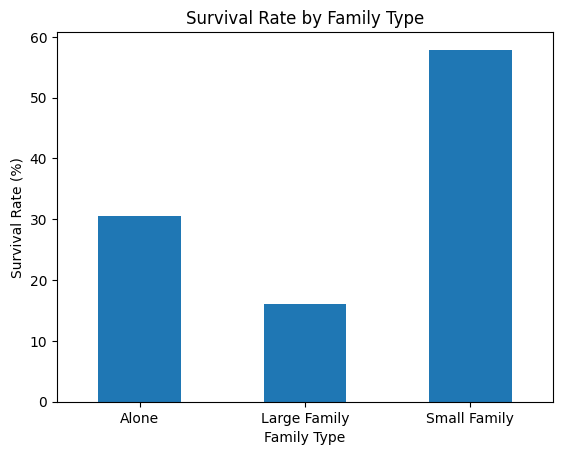

In [ ]:
survival_rate.plot(kind='bar')

plt.title('Survival Rate by Family Type')
plt.xlabel('Family Type')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Fare statistics
min_fare = data["Fare"].min()
max_fare = data["Fare"].max()
avg_fare = data["Fare"].mean()
median_fare = data["Fare"].median()

print("FARE ANALYSIS")
print("-" * 30)
print(f"Minimum Fare : £{min_fare:.2f}")
print(f"Maximum Fare : £{max_fare:.2f}")
print(f"Average Fare : £{avg_fare:.2f}")
print(f"Median Fare  : £{median_fare:.2f}")

FARE ANALYSIS
------------------------------
Minimum Fare : £0.00
Maximum Fare : £512.33
Average Fare : £32.31
Median Fare  : £14.45


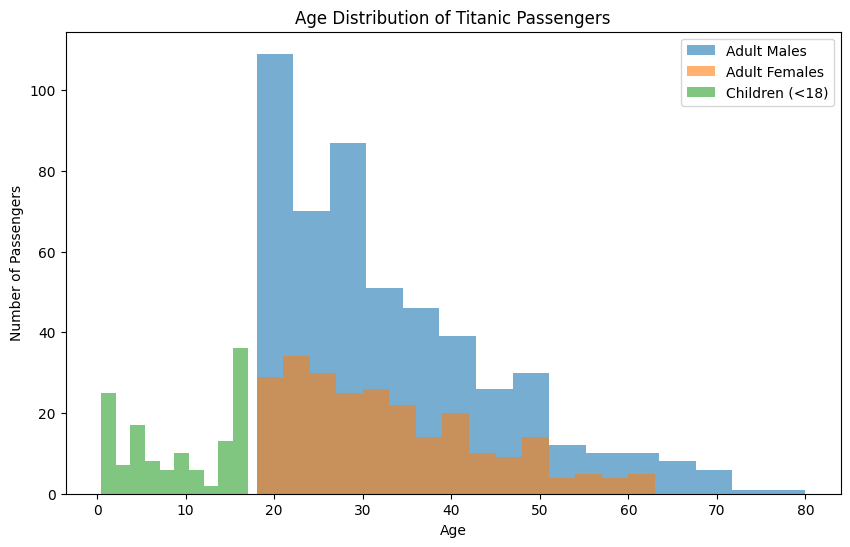

In [ ]:
# Create groups
adult_males = data[
    (data["Sex"] == "male") &
    (data["Age"] >= 18)
]["Age"].dropna()

adult_females = data[
    (data["Sex"] == "female") &
    (data["Age"] >= 18)
]["Age"].dropna()

children = data[
    data["Age"] < 18
]["Age"].dropna()

# Plot histogram
plt.figure(figsize=(10, 6))

plt.hist(adult_males, bins=15, alpha=0.6, label="Adult Males")
plt.hist(adult_females, bins=15, alpha=0.6, label="Adult Females")
plt.hist(children, bins=10, alpha=0.6, label="Children (<18)")

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()

plt.show()

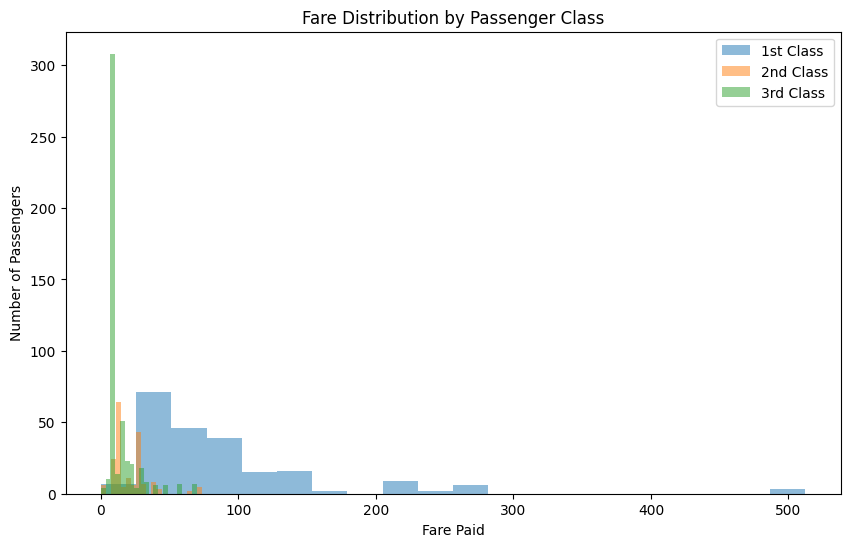

In [ ]:
# Create figure
plt.figure(figsize=(10, 6))

# Histogram for each class
plt.hist(
    data[data["Pclass"] == 1]["Fare"].dropna(),
    bins=20,
    alpha=0.5,
    label="1st Class"
)

plt.hist(
    data[data["Pclass"] == 2]["Fare"].dropna(),
    bins=20,
    alpha=0.5,
    label="2nd Class"
)

plt.hist(
    data[data["Pclass"] == 3]["Fare"].dropna(),
    bins=20,
    alpha=0.5,
    label="3rd Class"
)

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Fare Paid")
plt.ylabel("Number of Passengers")
plt.legend()

plt.show()

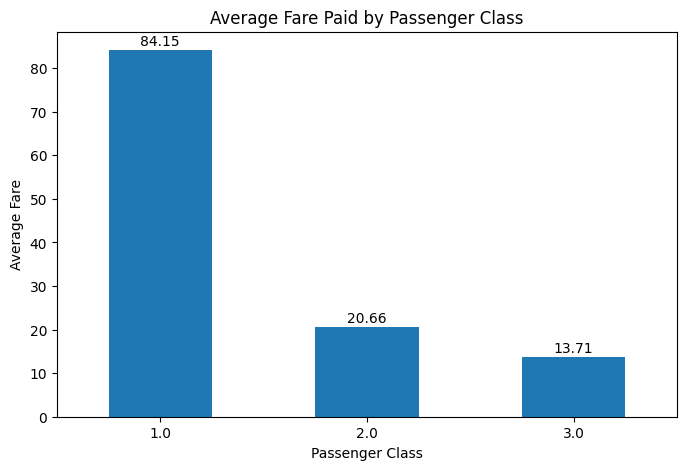

In [ ]:


# Calculate average fare for each class
avg_fare = data.groupby("Pclass")["Fare"].mean()

# Create bar graph
plt.figure(figsize=(8, 5))
avg_fare.plot(kind="bar")

plt.title("Average Fare Paid by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")
plt.xticks(rotation=0)

# Add values on top of bars
for i, value in enumerate(avg_fare):
    plt.text(i, value + 1, f"{value:.2f}", ha="center")

plt.show()

In [ ]:
# Create groups
male = data[data["Sex"] == "male"]
female = data[data["Sex"] == "female"]
children = data[data["Age"] < 18]

# Calculate statistics
survival_data = {
    "Category": ["Male", "Female", "Children (<18)"],
    "Total Passengers": [
        len(male),
        len(female),
        len(children)
    ],
    "Survived": [
        male["Survived"].sum(),
        female["Survived"].sum(),
        children["Survived"].sum()
    ]
}

# Create DataFrame
result = pd.DataFrame(survival_data)

# Calculate survival rate
result["Survival Rate (%)"] = (
    result["Survived"] /
    result["Total Passengers"] * 100
).round(2)

# Display report
print("\nTITANIC SURVIVAL ANALYSIS")
print("=" * 70)
print(result.to_string(index=False))
print("=" * 70)

results = []
for cls in sorted(data["Pclass"].unique()):

    survivors = data[
        (data["Pclass"] == cls) &
        (data["Survived"] == 1)
    ]

    adult_males = len(
        survivors[
            (survivors["Sex"] == "male") &
            (survivors["Age"] >= 18)
        ]
    )

    adult_females = len(
        survivors[
            (survivors["Sex"] == "female") &
            (survivors["Age"] >= 18)
        ]
    )

    children = len(
        survivors[
            survivors["Age"] < 18
        ]
    )

    total_survivors = (
        adult_males +
        adult_females +
        children
    )

    results.append([
        cls,
        adult_males,
        adult_females,
        children,
        total_survivors
    ])

output = pd.DataFrame(
    results,
    columns=[
        "Class",
        "Adult Male Survivors",
        "Adult Female Survivors",
        "Child Survivors",
        "Total Survivors"
    ]
)

print("\nSURVIVORS BY CLASS (MUTUALLY EXCLUSIVE)")
print("=" * 80)
print(output.to_string(index=False))
print("=" * 80)


TITANIC SURVIVAL ANALYSIS
      Category  Total Passengers  Survived  Survival Rate (%)
          Male               573     109.0              19.02
        Female               314     233.0              74.20
Children (<18)               130      65.0              50.00

SURVIVORS BY CLASS (MUTUALLY EXCLUSIVE)
 Class  Adult Male Survivors  Adult Female Survivors  Child Survivors  Total Survivors
   1.0                    41                      84               11              136
   2.0                     8                      58               21               87
   3.0                    35                      51               33              119
   NaN                     0                       0                0                0



SURVIVORS BY CLASS

Class 1.0
Male Survivors   : 45
Female Survivors : 91
Total Survivors  : 136

Class 2.0
Male Survivors   : 17
Female Survivors : 70
Total Survivors  : 87

Class 3.0
Male Survivors   : 47
Female Survivors : 72
Total Survivors  : 119

Class nan
Male Survivors   : 0
Female Survivors : 0
Total Survivors  : 0


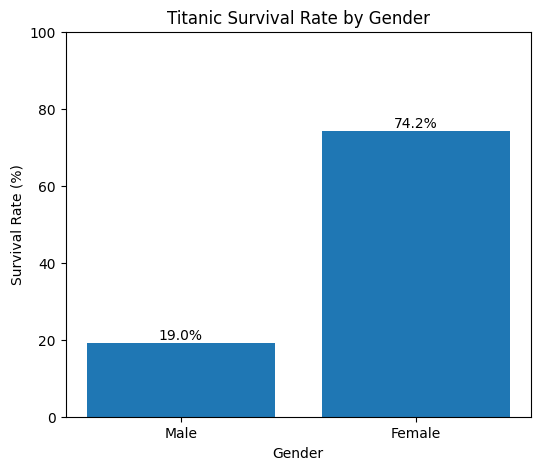

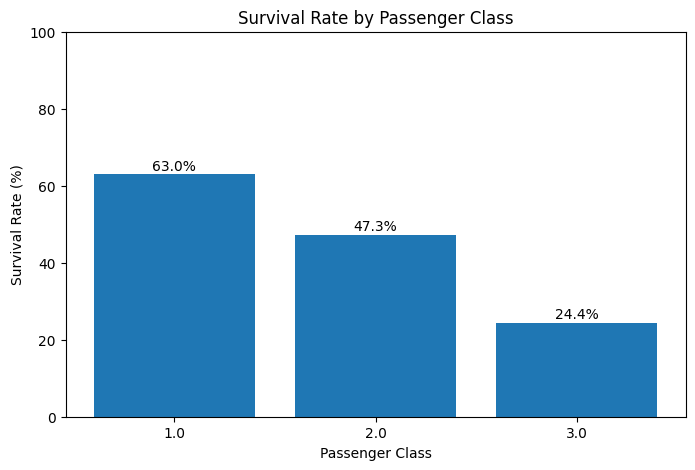

In [ ]:
#analyse how many males and females survived in each class

print("\nSURVIVORS BY CLASS")
print("=" * 50)

for cls in sorted(data["Pclass"].unique()):

    male_survivors = len(
        data[
            (data["Pclass"] == cls) &
            (data["Sex"] == "male") &
            (data["Survived"] == 1)
        ]
    )

    female_survivors = len(
        data[
            (data["Pclass"] == cls) &
            (data["Sex"] == "female") &
            (data["Survived"] == 1)
        ]
    )

    total = male_survivors + female_survivors

    print(f"\nClass {cls}")
    print(f"Male Survivors   : {male_survivors}")
    print(f"Female Survivors : {female_survivors}")
    print(f"Total Survivors  : {total}")

# Calculate survival rates
male_rate = data[data["Sex"] == "male"]["Survived"].mean() * 100
female_rate = data[data["Sex"] == "female"]["Survived"].mean() * 100

# Data
categories = ["Male", "Female"]
rates = [male_rate, female_rate]

# Plot
plt.figure(figsize=(6, 5))
plt.bar(categories, rates)

plt.title("Titanic Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

# Add values on bars
for i, rate in enumerate(rates):
    plt.text(i, rate + 1, f"{rate:.1f}%", ha="center")

plt.ylim(0, 100)
plt.show()

# Calculate survival rate (%) for each class
survival_rate = (
    data.groupby("Pclass")["Survived"]
    .mean() * 100
)

# Create bar plot
plt.figure(figsize=(8, 5))
plt.bar(
    survival_rate.index.astype(str),
    survival_rate.values
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

# Display values on top of bars
for i, rate in enumerate(survival_rate.values):
    plt.text(i, rate + 1, f"{rate:.1f}%", ha="center")

plt.ylim(0, 100)
plt.show()

                                                  Name     Embarked
0                               Mr. Owen Harris Braund  Southampton
1    Mrs. John Bradley (Florence Briggs Thayer) Cum...    Cherbourg
2                                Miss. Laina Heikkinen  Southampton
3          Mrs. Jacques Heath (Lily May Peel) Futrelle  Southampton
4                              Mr. William Henry Allen  Southampton
..                                                 ...          ...
886                                 Mr. Patrick Dooley  Southampton
887                                                NaN  Southampton
888                                                NaN  Southampton
889                                                NaN    Cherbourg
890                                                NaN   Queenstown

[891 rows x 2 columns]
Embarked
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64


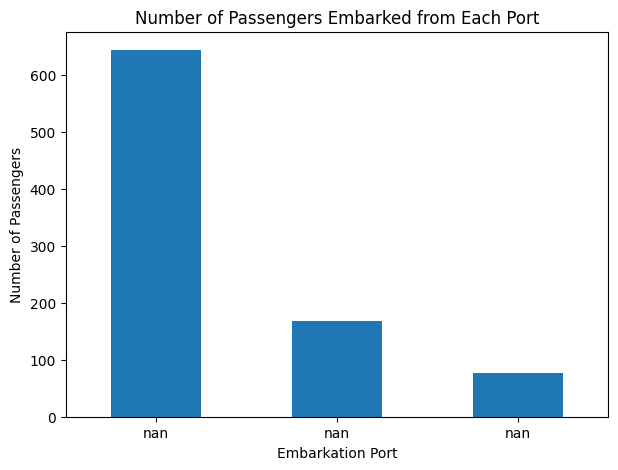

In [ ]:

# Replace codes with port names
data["Embarked"] = data["Embarked"].replace({
    "C": "Cherbourg",
    "Q": "Queenstown",
    "S": "Southampton"
})

# Display passenger name and embarkation port
print(data[["Name", "Embarked"]])

data["Embarked"] = data["Embarked"].replace({
    "C": "Cherbourg",
    "Q": "Queenstown",
    "S": "Southampton"
})

print(data["Embarked"].value_counts())

# Keep only Embarked column and drop missing values
df = data[['Embarked']].dropna()

# Count passengers per port
embarked_counts = df['Embarked'].value_counts()

# Optional: rename ports for clarity
embarked_counts.index = embarked_counts.index.map({
    "C": "Cherbourg",
    "Q": "Queenstown",
    "S": "Southampton"
})

# Plot bar chart
plt.figure(figsize=(7,5))
embarked_counts.plot(kind='bar')

plt.title("Number of Passengers Embarked from Each Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)

plt.show()

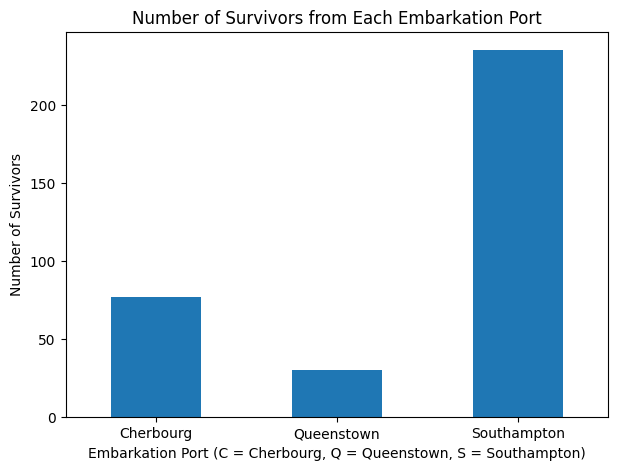

In [ ]:

df = data[['Survived', 'Embarked']]

# Drop missing values
df = data.dropna()

# Group by Embarked and count survivors (Survived = 1)
survivors_by_port = df[df['Survived'] == 1].groupby('Embarked').size()

# Plot bar graph
plt.figure(figsize=(7,5))
survivors_by_port.plot(kind='bar')

plt.title("Number of Survivors from Each Embarkation Port")
plt.xlabel("Embarkation Port (C = Cherbourg, Q = Queenstown, S = Southampton)")
plt.ylabel("Number of Survivors")

plt.xticks(rotation=0)
plt.show()

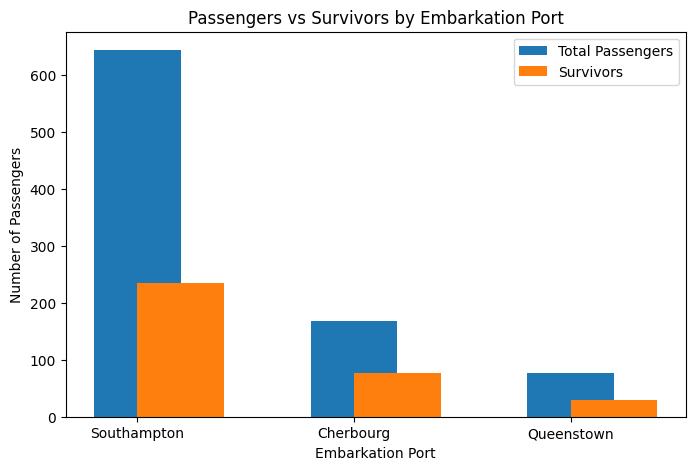

In [ ]:
# Total passengers per port
total_passengers = data["Embarked"].value_counts()

# Survivors per port (assuming you still have Survived column: 1 = survived)
survivors = data[data["Survived"] == 1]["Embarked"].value_counts()

# Combine into one DataFrame-like structure
ports = total_passengers.index

total = total_passengers.reindex(ports)
survived = survivors.reindex(ports).fillna(0)

# Plot
plt.figure(figsize=(8,5))

x = range(len(ports))

plt.bar(x, total, width=0.4, label="Total Passengers", align='center')
plt.bar(x, survived, width=0.4, label="Survivors", align='edge')

plt.xticks(x, ports, rotation=0)
plt.xlabel("Embarkation Port")
plt.ylabel("Number of Passengers")
plt.title("Passengers vs Survivors by Embarkation Port")
plt.legend()

plt.show()